In [37]:
import seaborn as sns
import numpy as np

### questions: how to reliably predict arguments? e.g. filter_genes(n_cells=20), how this 20 be specified in a reliable way? Shouldn't 20 be dependent on certain statistics of data?

# query

Provide the python code for trajectory inference with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.

# old

In [30]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic filtering (if further preprocessing needed, add here)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
print(adata)

# Normalize and log-transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var['highly_variable']]

# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

# Run PCA to reduce dimensionality
sc.tl.pca(adata, svd_solver='arpack')

# Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Run UMAP for visualization
sc.tl.umap(adata)

# Run the Louvain algorithm for clustering
sc.tl.louvain(adata)

# Run PAGA to infer trajectories
sc.tl.paga(adata, groups='louvain')
sc.pl.paga(adata, color=['louvain'])

# Optionally compute a UMAP initialized with the PAGA-initialized positions
sc.tl.umap(adata, init_pos='paga')
sc.pl.umap(adata, color='louvain')

AnnData object with n_obs × n_vars = 538 × 1827
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


TypeError: putmask: first argument must be an array

### Note that original report said "This is also an open [issue](https://github.com/scverse/scanpy/issues/3070) submitted by other users." However, this issue is not resolved, and one more problem is raised in the issue. Referring to this issue would not help biomania to solve the problem.

### The first argument of highly_variable_genes() requires an adata rather than a numpy.adarray. Simply referring to the error message might let biomania replace adata by adata.X or some other arrays, not resolving the problem.

### Note that similar to scanpy_1, adata.X has nan problem. Maybe it's a problem?

In [4]:
adata.X

array([[3.404975 , 3.9427435, 2.132463 , ..., 3.6164215, 3.7724435,
        4.406126 ],
       [      nan,       nan,       nan, ...,       nan,       nan,
        6.807554 ],
       [3.9965672,       nan, 2.4781756, ..., 3.730794 , 3.918631 ,
        4.710094 ],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
        4.2270174],
       [      nan, 5.671832 ,       nan, ...,       nan,       nan,
              nan],
       [5.849314 ,       nan, 3.9807463, ..., 5.0832496, 5.098383 ,
        6.1105666]], dtype=float32)

## sol 1: remove log1p
* it looks like the problem above is resulted from log1p. After this problem being resolved, another problem appears.

In [29]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic filtering (if further preprocessing needed, add here)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize and log-transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:295: RuntimeWarning: overflow encountered in expm1
  np.expm1(X, out=X)
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/_utils/__init__.py:553: RuntimeWarning: overflow encountered in multiply
  return x * y
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_utils.py:41: RuntimeWarning: invalid value encountered in subtract
  var = mean_sq - mean**2


ValueError: cannot specify integer `bins` when input data contains infinity

### warning 1: some cells have zero counts after cells with expressed genes less than 200 being removed.

In [31]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic filtering (if further preprocessing needed, add here)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)


In [48]:
(adata.X.sum(1) < 0).sum()

166

### As per source codes shown below, cells are considered having zero counts when counts values < 0. In other words, this warning indicates the dataset may already be preprocessed, thus no preprocessing needed. Hence remove normalize_total() from here.

```python
# https://github.com/scverse/scanpy/blob/main/src/scanpy/preprocessing/_normalization.py, L231
counts_per_cell = np.ravel(counts_per_cell)

cell_subset = counts_per_cell > 0
if not isinstance(cell_subset, DaskArray) and not np.all(cell_subset):
    warn(UserWarning("Some cells have zero counts"))

```

In [73]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic filtering (if further preprocessing needed, add here)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize and log-transform the data
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:305: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


In [74]:
adata

AnnData object with n_obs × n_vars = 538 × 1827
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'hvg'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### now it works, and some of other original warnings also disappear. Here we have a new warning. let's see this warning 

### warning 2: invalid value encountered in log, dispersion = np.log(dispersion)

### According to source codes shown below, highly_variable_genes() API would assume that input data must have been log1p. Then it will expm1 data back to its (and also mean) original version, compute true dispersion, than log mean and dispersion, than Z-normalization. The reason is, if directlt mean on log1p version of X, it will be actually log1p on geometric mean of X rather than average. It's not desired for some reasons.
```python
# https://github.com/scverse/scanpy/blob/main/src/scanpy/preprocessing/_highly_variable_genes.py#L268
if flavor == "seurat":
    X = X.copy()
    if (base := adata.uns.get("log1p", {}).get("base")) is not None:
        X *= np.log(base)
    # use out if possible. only possible since we copy the data matrix
    if isinstance(X, np.ndarray):
        np.expm1(X, out=X)
    else:
        X = np.expm1(X)

mean, var = materialize_as_ndarray(_get_mean_var(X))
# now actually compute the dispersion
mean[mean == 0] = 1e-12  # set entries equal to zero to small value
dispersion = var / mean
if flavor == "seurat":  # logarithmized mean as in Seurat
    dispersion[dispersion == 0] = np.nan
    dispersion = np.log(dispersion)
    mean = np.log1p(mean)
```

In [49]:
np.expm1(adata.X)

array([[-0.19312154, -0.3110957 , -0.05332974, ..., -0.23420753,
        -0.26885667, -0.4493492 ],
       [-0.31400675, -0.25553116, -0.05590408, ..., -0.14671013,
        -0.15707427,  2.9709284 ],
       [-0.23451252, 10.282465  , -0.05317005, ..., -0.18429598,
        -0.21872678, -0.42345318],
       ...,
       [-0.32920435, -0.29069138, -0.05992363, ..., -0.21917605,
        -0.20210066,  1.7541533 ],
       [-0.25201175, 12.989474  , -0.05305077, ..., -0.16020094,
        -0.1948396 , -0.41131857],
       [-0.32046285, 13.192255  , -0.05699691, ..., -0.16388558,
        -0.16617869, -0.39469427]], dtype=float32)

### explanations: it looks like original X (all positive, count matrix) is transformed by other operations besides log1p, so X are still negative after inverse operation of log1p (expm1). This makes mean of each column being negative, and thus dispersion being negative, and thus invalid log(dispersion). If original X is count matrix, this problem would not happen since mean of each column must be positive.

### note that _get_mean_var() is the same as vanilla mean and var, just to deal with some misc operations.

### to solve this problem, we can remove invalid cells and see if following codes can work after highly_variable_genes(). <u>But note that, subsequent codes are just to test whether more bugs occur, but are already invalid since applying highly...() to preprocessed pbmc3k doesn't make sense.</u>

In [75]:
adata = adata[:, ~(adata.var['dispersions'] < 0.)]

In [76]:
adata = adata[:, adata.var['highly_variable']]

In [77]:
# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:672: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


KeyError: "None of [Index(['total_counts', 'pct_counts_mt'], dtype='object')] are in the [columns]"

### this problem occurs because these columns, which should be generated by quality control in prior, are not generated. gpt4 seems easily mess up with these steps dependencies. To temporally solve this problem, I choose a simple QC.

In [89]:
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["ribo"], percent_top=[50], inplace=True
)

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [91]:
adata.var["ribo"].sum()

2

### this is actually a problem, log1p cannot be applied to X if it has already been log1p, though log1p is a default option in calculate_qc_metrics and log1p is also usually applied to X in preprocessing steps.

In [92]:
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["ribo"], percent_top=[50], inplace=True, log1p=False
)

In [94]:
adata

AnnData object with n_obs × n_vars = 538 × 340
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'hvg'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [93]:
# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

KeyError: "['pct_counts_mt'] not in index"

### We see that the problem of 'pct_counts_mt' still exists. That because gpt4 (and biomania as well) doesn't know 1) which var exists (and the meaning of var), and 2) mt has not been considered in qc_control. In other words, biomania needs to know 1) what var exists and what they are, and 2) what preprocessing steps being conducted, to resolve these problems.

### Let's resolve it by using the actual 'pct_counts_ribo'

In [95]:
# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_ribo'])

In [96]:
# Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [97]:
# Run PCA to reduce dimensionality
sc.tl.pca(adata, svd_solver='arpack')

In [98]:
# Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

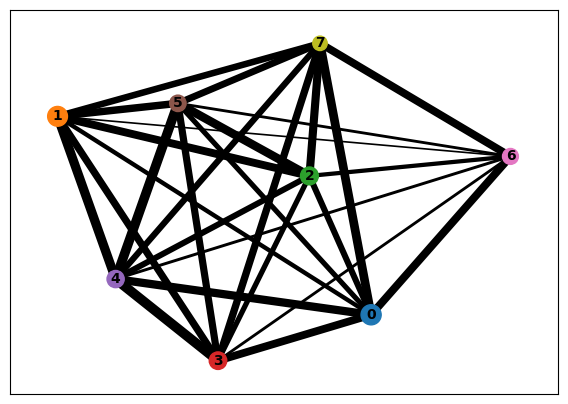

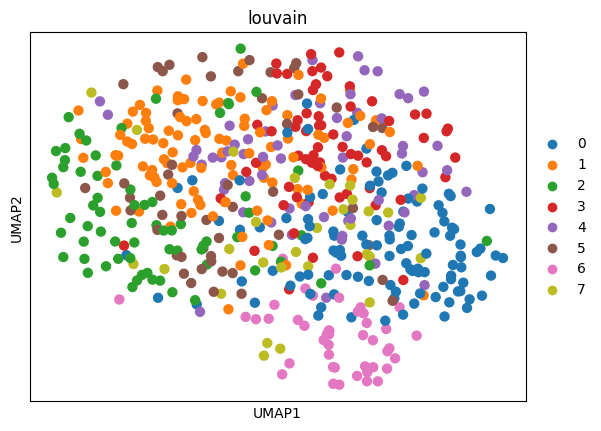

In [99]:
# Run UMAP for visualization
sc.tl.umap(adata)

# Run the Louvain algorithm for clustering
sc.tl.louvain(adata)

# Run PAGA to infer trajectories
sc.tl.paga(adata, groups='louvain')
sc.pl.paga(adata, color=['louvain'])

# Optionally compute a UMAP initialized with the PAGA-initialized positions
sc.tl.umap(adata, init_pos='paga')
sc.pl.umap(adata, color='louvain')

### great! it works! although I am not sure whether results are right for this query. But at least it can run now. The fixed codes shown below

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:305: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_23639/998097206.py:19: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))


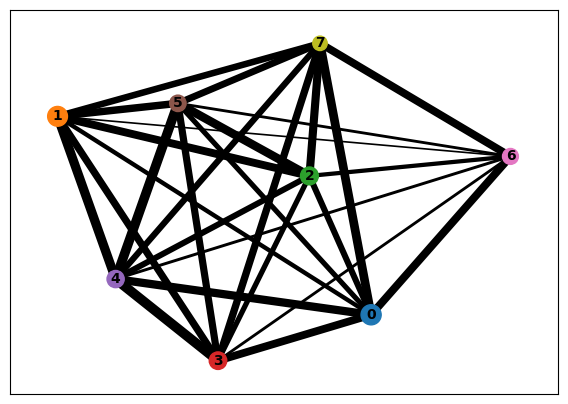

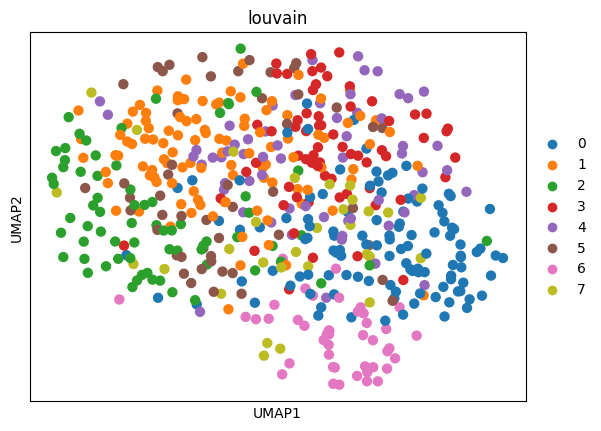

In [101]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic filtering (if further preprocessing needed, add here)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize and log-transform the data
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

adata = adata[:, ~(adata.var['dispersions'] < 0.)]
adata = adata[:, adata.var['highly_variable']]

adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["ribo"], percent_top=[50], inplace=True, log1p=False
)

# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_ribo'])

# Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)
# Run PCA to reduce dimensionality
sc.tl.pca(adata, svd_solver='arpack')
# Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
# Run UMAP for visualization
sc.tl.umap(adata)

# Run the Louvain algorithm for clustering
sc.tl.louvain(adata)

# Run PAGA to infer trajectories
sc.tl.paga(adata, groups='louvain')
sc.pl.paga(adata, color=['louvain'])

# Optionally compute a UMAP initialized with the PAGA-initialized positions
sc.tl.umap(adata, init_pos='paga')
sc.pl.umap(adata, color='louvain')

### TODO: it seems that even if log1p is set in calculate_qc_metrics, codes can still work

## sol 2: use original data. If this strategy can work for most scanpy cases, one solution for biomania can be, we can first simply require users to input original count matrix. Then we figure out how to loosen this constraint in biomania to empower it.

In [102]:
import scanpy as sc

# Load the example dataset
# adata = sc.datasets.pbmc3k_processed()
adata = sc.datasets.pbmc3k()

# Basic filtering (if further preprocessing needed, add here)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize and log-transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [103]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var['highly_variable']]

In [104]:
# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:672: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


KeyError: "None of [Index(['total_counts', 'pct_counts_mt'], dtype='object')] are in the [columns]"

### same problem as above.

In [105]:
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["ribo"], percent_top=[50], inplace=True, log1p=False
)
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_ribo'])

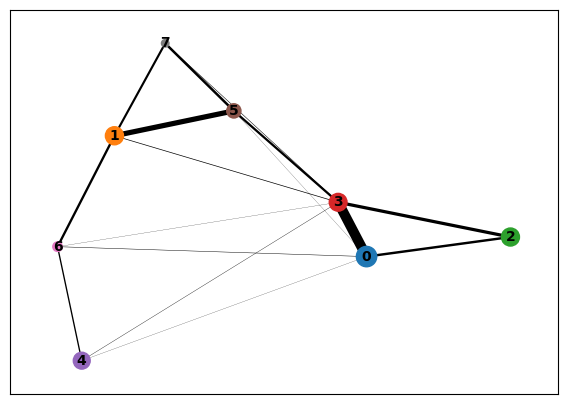

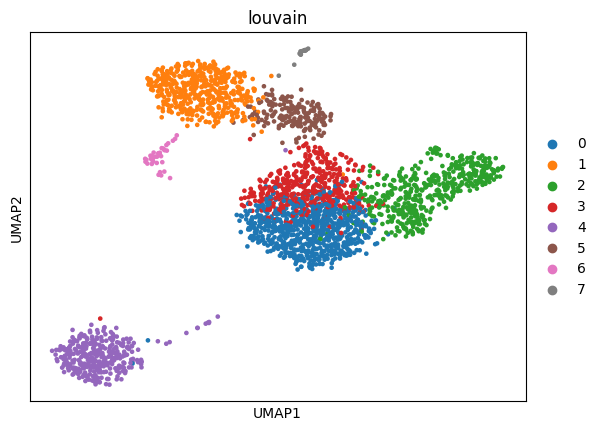

In [106]:
# Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

# Run PCA to reduce dimensionality
sc.tl.pca(adata, svd_solver='arpack')

# Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Run UMAP for visualization
sc.tl.umap(adata)

# Run the Louvain algorithm for clustering
sc.tl.louvain(adata)

# Run PAGA to infer trajectories
sc.tl.paga(adata, groups='louvain')
sc.pl.paga(adata, color=['louvain'])

# Optionally compute a UMAP initialized with the PAGA-initialized positions
sc.tl.umap(adata, init_pos='paga')
sc.pl.umap(adata, color='louvain')

### great! if we require inputs to be only original count matrix, many problems can be solved, with only one problem left. Actually this result makes much sense than sol 1 by looking at clustering result and graph. Corrected codes as below:

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_23639/378973083.py:19: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))


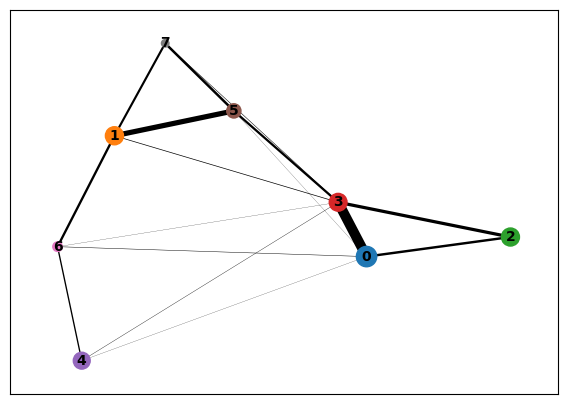

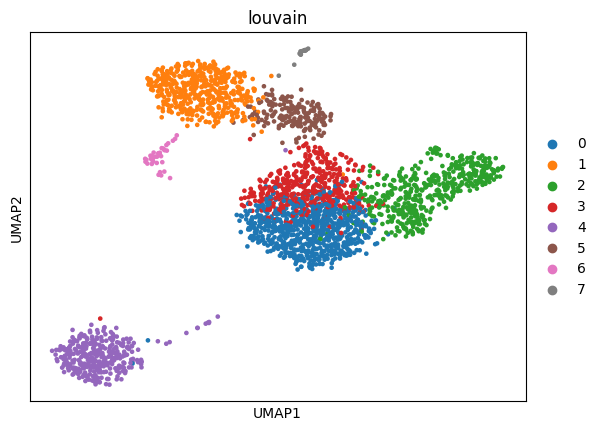

In [142]:
import scanpy as sc

# Load the example dataset
# adata = sc.datasets.pbmc3k_processed()
adata = sc.datasets.pbmc3k()

# Basic filtering (if further preprocessing needed, add here)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize and log-transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var['highly_variable']]

adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["ribo"], percent_top=[50], inplace=True, log1p=False
)
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_ribo'])

# Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

# Run PCA to reduce dimensionality
sc.tl.pca(adata, svd_solver='arpack')

# Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Run UMAP for visualization
sc.tl.umap(adata)

# Run the Louvain algorithm for clustering
sc.tl.louvain(adata)

# Run PAGA to infer trajectories
sc.tl.paga(adata, groups='louvain')
sc.pl.paga(adata, color=['louvain'])

# Optionally compute a UMAP initialized with the PAGA-initialized positions
sc.tl.umap(adata, init_pos='paga')
sc.pl.umap(adata, color='louvain')

# new

In [123]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Calculate the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')
# Compute UMAP for visualization
sc.tl.umap(adata)
# Perform clustering
sc.tl.leiden(adata)
# Infer the trajectory (pseudotime)
sc.tl.diffmap(adata)

In [124]:
sc.tl.dpt(adata)

    adata.uns['iroot'] = root_cell_index
    adata.var['xroot'] = adata[root_cell_name, :].X


KeyError: 'dpt_pseudotime'

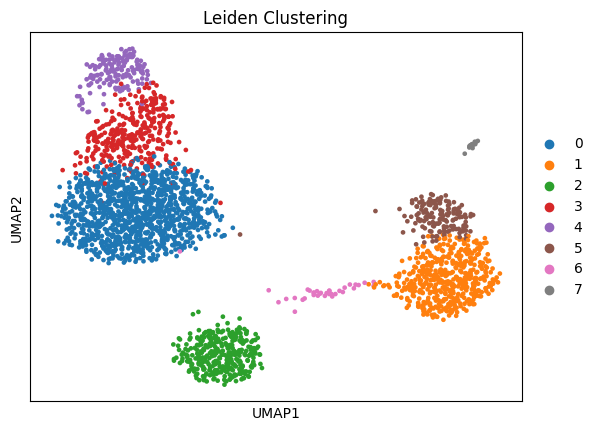

In [125]:
sc.pl.umap(adata, color=['leiden', 'dpt_pseudotime'], title=['Leiden Clustering', 'Diffusion Pseudotime'])

### sol 1: it looks like something wrong with diffmap and dpt. There is no result named "dpt_pseudotime"

### diffmap has no problem.

In [127]:
adata.obsm['X_diffmap'].shape

(2638, 15)

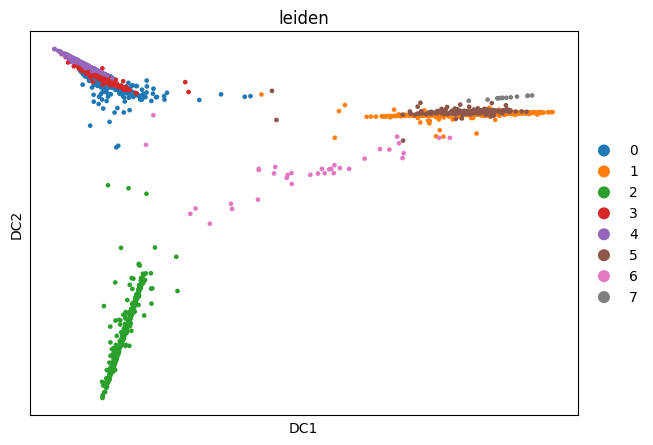

In [135]:
sc.pl.scatter(
    adata,
    basis="diffmap",
    color=["leiden"],
    components=[1, 2],
)

### The problem happens because the initial cell is not set up. I don't know how to set up it so I just follow scanpy tutorial. Maybe what I do makes no sense.

### For biomania, this problem can be solved by 1) + 2), where 1) is referring to warning of dpt(), and 2) is scanpy tutorial. 

### Question: However, how do bioma know whether the setup initial cell makes sense (hyperparam), if bioma has no access to data statistics, analysis result and judgement standard of analysis? e.g. "Different pseudotime methods give different results. Sometimes, one pseudotime captures the underlying developmental processes more accurately." -- scanpy tutorial

In [137]:
root_ixs = adata.obsm["X_diffmap"][:, 3].argmin()
adata.uns["iroot"] = root_ixs

In [138]:
sc.tl.dpt(adata)

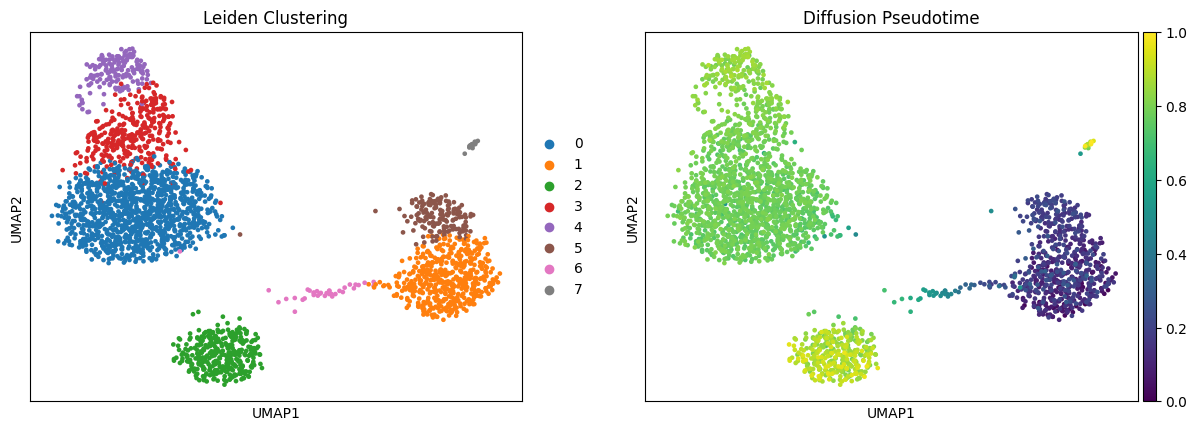

In [140]:
sc.pl.umap(adata, color=['leiden', 'dpt_pseudotime'], title=['Leiden Clustering', 'Diffusion Pseudotime'])

### now it works pretty well! Let's try some other vis. There's no need 

### Questions: how to judge if this TI is good?

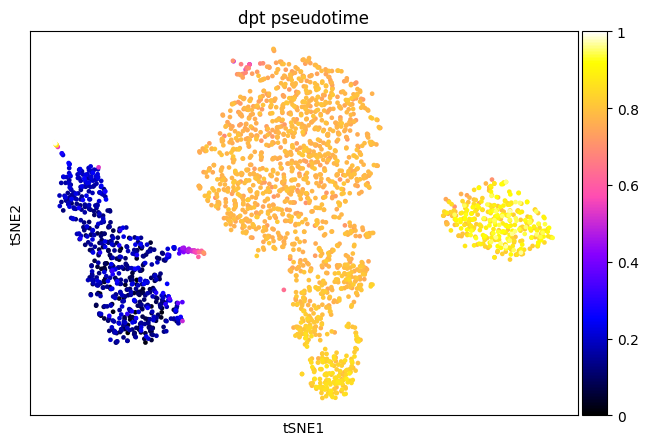

In [141]:
sc.pl.scatter(
    adata,
    basis="tsne",
    color=["dpt_pseudotime"],
    color_map="gnuplot2",
)

### sol 2: try using original dataset

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


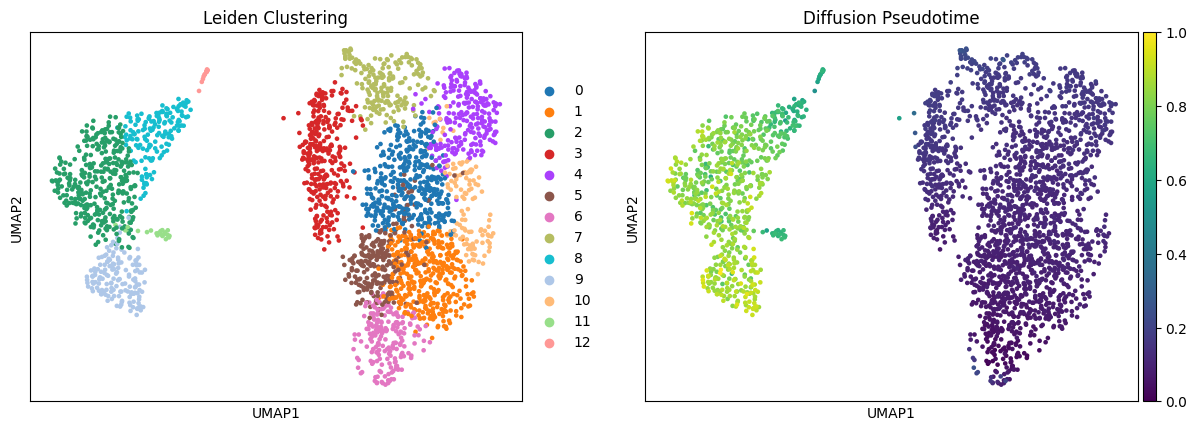

In [149]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k()

# Jiahang (debug): pca is necessary
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=False)
# Calculate the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')
# Compute UMAP for visualization
sc.tl.umap(adata)
# Perform clustering
sc.tl.leiden(adata)
# Infer the trajectory (pseudotime)
sc.tl.diffmap(adata)

# Jiahang: we already know that these two steps are necessary no matter preprocessed or 
# original dataset is used.
root_ixs = adata.obsm["X_diffmap"][:, 3].argmin()
adata.uns["iroot"] = root_ixs

sc.tl.dpt(adata)

sc.pl.umap(adata, color=['leiden', 'dpt_pseudotime'], title=['Leiden Clustering', 'Diffusion Pseudotime'])

### Question: one error occurs when neighbors() is executed. It needs a prior call to pca(). To debug it, I add pca(). note that neighbors() is necessary for diffmap(). is it possible that some unnecessary API calls result in errors? if yes, the debug should not be fix them, but to remove them.